In [1]:
import omicverse as ov
#print(f"omicverse version: {ov.__version__}")
import scanpy as sc
#print(f"scanpy version: {sc.__version__}")
ov.utils.ov_plot_set()


   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

Version: 1.5.8, Tutorials: https://omicverse.readthedocs.io/


In [2]:
adata = sc.read_h5ad('Ductal_cells_subtype_duc2_X7.h5ad')
adata

AnnData object with n_obs × n_vars = 37960 × 19695
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'source', 'stage', 'leiden', 'leiden_res0_25', 'major_celltype', 'batch', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden_T', 'leidenT_res0_25.', 'leidenT_res0_5.', 'score', 'classical_score', 'basal_score', 'subtype_score_cluster', 'ident', 'active_ident'
    uns: 'leidenT_res0_25.', 'leidenT_res0_25._colors', 'leidenT_res0_5.', 'leidenT_res0_5._colors', 'leiden_T', 'leiden_T_colors', 'major_celltype_colors', 'neighbors', 'orig.ident_colors', 'scaled|original|cum_sum_eigenvalues', 'scaled|original|pca_var_ratios', 'source_colors', 'subtype_score_cluster_colors', 'umap'
    obsm: 'X_harmony', 'X_mde', 'X_mde_T_harmony', 'X_mde_harmony', 'X_mde_pca', 'X_pca', 'X_pca_harmony', 'X_pca_semi', 'X_umap', 'scaled|original|X_pca'
    layers: 'scaled'
    obsp: 'connectivities', 'distances'

<AxesSubplot: title={'center': 'subtype_score_cluster'}, xlabel='X_umap1', ylabel='X_umap2'>

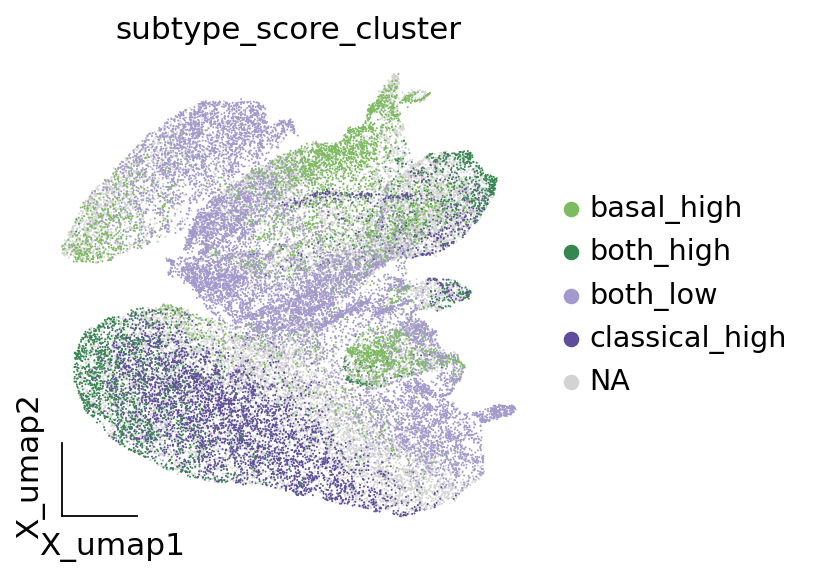

In [3]:
%matplotlib inline
ov.utils.embedding(adata,
                basis='X_umap',
                color=['subtype_score_cluster'],
                palette=ov.palette()[:],
                show=False,frameon='small',)

In [4]:
adata_hi = adata[adata.obs['subtype_score_cluster'].isin(['basal_high', 'classical_high'])]
adata_hi

View of AnnData object with n_obs × n_vars = 8412 × 19695
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'source', 'stage', 'leiden', 'leiden_res0_25', 'major_celltype', 'batch', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden_T', 'leidenT_res0_25.', 'leidenT_res0_5.', 'score', 'classical_score', 'basal_score', 'subtype_score_cluster', 'ident', 'active_ident'
    uns: 'leidenT_res0_25.', 'leidenT_res0_25._colors', 'leidenT_res0_5.', 'leidenT_res0_5._colors', 'leiden_T', 'leiden_T_colors', 'major_celltype_colors', 'neighbors', 'orig.ident_colors', 'scaled|original|cum_sum_eigenvalues', 'scaled|original|pca_var_ratios', 'source_colors', 'subtype_score_cluster_colors', 'umap'
    obsm: 'X_harmony', 'X_mde', 'X_mde_T_harmony', 'X_mde_harmony', 'X_mde_pca', 'X_pca', 'X_pca_harmony', 'X_pca_semi', 'X_umap', 'scaled|original|X_pca'
    layers: 'scaled'
    obsp: 'connectivities', 'distances'

<AxesSubplot: title={'center': 'subtype_score_cluster'}, xlabel='X_umap1', ylabel='X_umap2'>

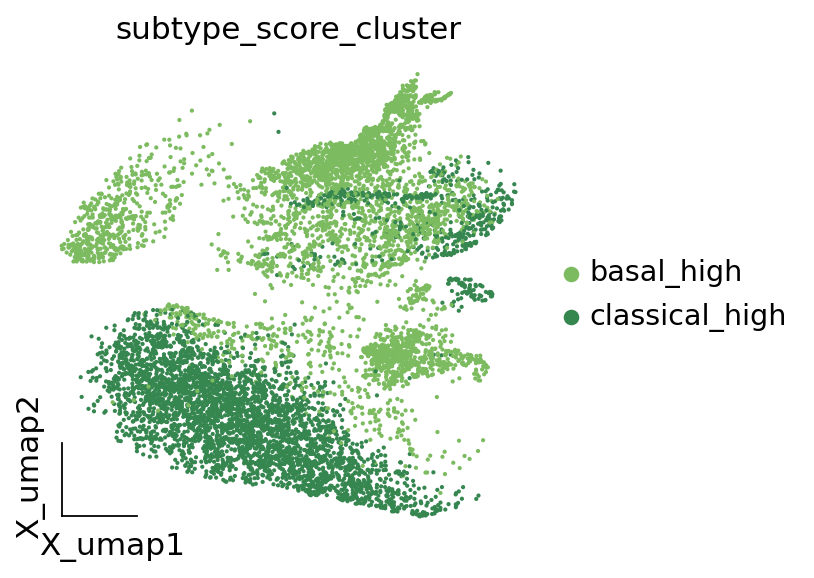

In [5]:
%matplotlib inline
ov.utils.embedding(adata_hi,
                basis='X_umap',
                color=['subtype_score_cluster'],
                palette=ov.palette()[:],
                show=False,frameon='small',)

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
from scipy.stats import pearsonr

In [7]:
gene_expression = adata_hi.to_df()
lypla1_expression = gene_expression['LYPLA1'].values
correlations = np.zeros(gene_expression.shape[1])
for i in range(gene_expression.shape[1]):
    correlations[i] = pearsonr(lypla1_expression, gene_expression.iloc[:, i].values)[0]

lypla1_correlations = pd.Series(correlations, index=gene_expression.columns)
top_50_related = lypla1_correlations.sort_values(ascending=False).index[1:51]  
bottom_50_related = lypla1_correlations.sort_values().index[:50]

selected_genes = list(top_50_related) + list(bottom_50_related)

selected_gene_expression = adata_hi[:, selected_genes].to_df()

In [9]:
print(top_50_related,bottom_50_related)

Index(['RPL7', 'NAP1L1', 'PSMA1', 'SELENOM', 'RPL17', 'RPS7', 'NPM1', 'LDHA',
       'RPL6', 'KRT7', 'RPS13', 'ANXA1', 'FTH1', 'ATP5MC2', 'PTGES3', 'EEF1G',
       'SLC25A3', 'PGK1', 'ATP5MC3', 'SUMO2', 'PABPC1', 'RPL5', 'MGST1',
       'TCEA1', 'GNG10', 'EIF3E', 'NDUFAB1', 'NACA', 'ST13', 'RPL3', 'TMED2',
       'SSR3', 'STMN1', 'POLR2K', 'RANBP1', 'FTL', 'RAB5IF', 'RPL8', 'NBDY',
       'SNX3', 'PSMA2', 'HSPD1', 'RPS4X', 'SUMO1', 'RPLP0', 'ARPC3', 'NDUFC2',
       'CD44', 'RAN', 'CDK2AP1'],
      dtype='object') Index(['SYTL2', 'TFF1', 'SULT1C2', 'CEACAM5', 'MUC5AC', 'MALAT1', 'MUC1',
       'CAPN8', 'CLDN18', 'ANKRD36C', 'MT-CO2', 'MT-CO1', 'ERN2', 'BCAS1',
       'MT-ND3', 'PHGR1', 'MT-ND5', 'LINC00342', 'TFF3', 'MICALL2', 'ABCC3',
       'CEACAM6', 'CYP3A5', 'MT-ATP6', 'ATP10B', 'ELF3', 'NEAT1', 'MT-ND4',
       'MT-ND2', 'MLPH', 'MUCL3', 'MT-CO3', 'HIST1H2BD', 'AL390719.2',
       'ARGLU1', 'KLF2', 'TCF7L2', 'LPCAT4', 'ARHGAP26', 'MUC3A', 'EPS8L1',
       'PLCG2', 'SPIRE2', 'LDLR

... as `zero_center=True`, sparse input is densified and may lead to large memory consumption


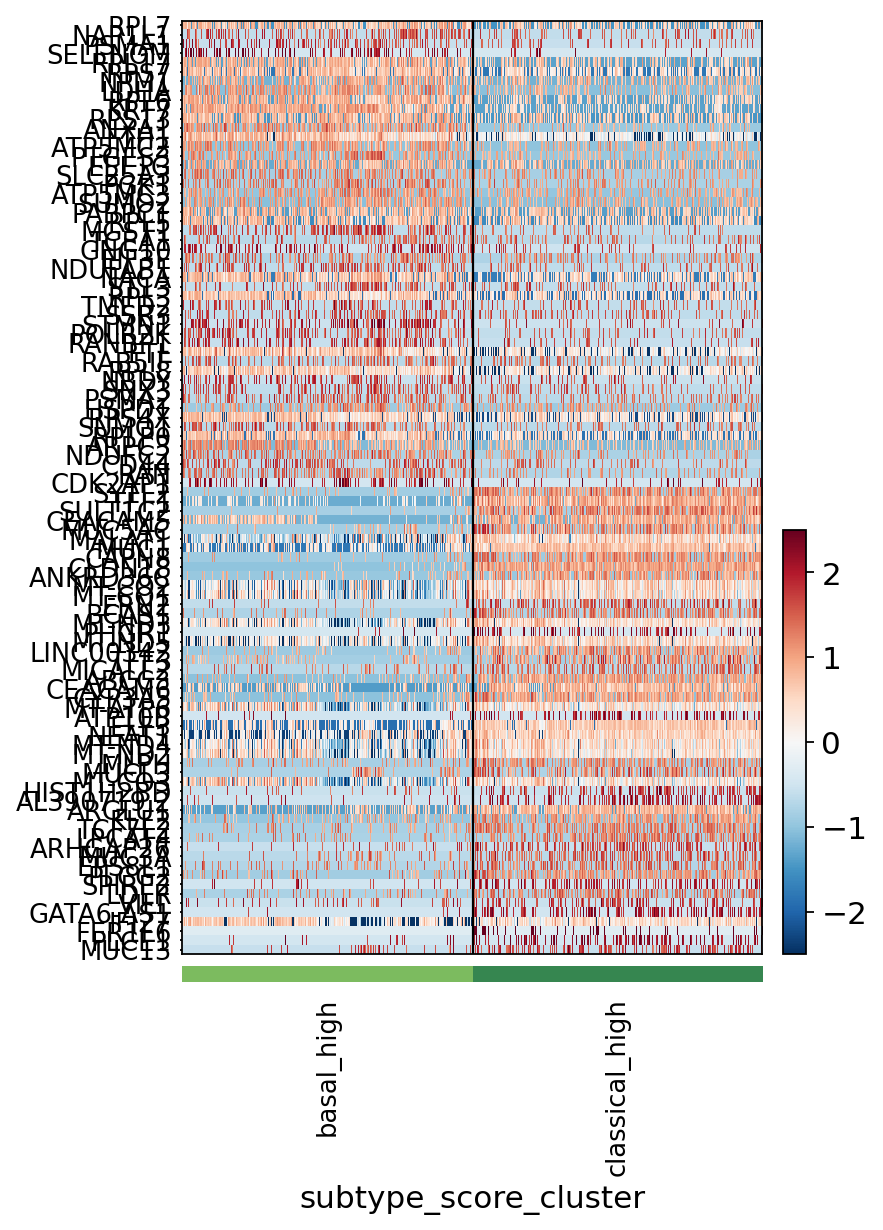

In [11]:
import scanpy as sc
import numpy as np

sc.pp.scale(adata_hi, zero_center=True, max_value=2.5, copy=False)
maxabs = np.max(np.abs(adata_hi.X))

sc.pl.heatmap(
    adata_hi,
    var_names=selected_genes,  
    groupby='subtype_score_cluster', 
    use_raw=False,  
    cmap='RdBu_r',  
    figsize=(5, 8),  
    show_gene_labels=True,  
    dendrogram=False,  
    standard_scale=None,  
    vmin=-maxabs,  
    vmax=maxabs,   
     swap_axes=True,
     save='X10.heatmap_LYPLA1_related-dc2_rdbu.pdf'  
)


In [12]:
gene_expression = adata_hi.to_df()
lypla1_expression = gene_expression['KRT17'].values
correlations = np.zeros(gene_expression.shape[1])
for i in range(gene_expression.shape[1]):
    correlations[i] = pearsonr(lypla1_expression, gene_expression.iloc[:, i].values)[0]
lypla1_correlations = pd.Series(correlations, index=gene_expression.columns)

top_50_related = lypla1_correlations.sort_values(ascending=False).index[1:51]  
bottom_50_related = lypla1_correlations.sort_values().index[:50]

selected_genes = list(top_50_related) + list(bottom_50_related)

selected_gene_expression = adata_hi[:, selected_genes].to_df()

In [13]:
print(top_50_related,bottom_50_related)

Index(['KRT7', 'C3', 'ANXA1', 'CST6', 'SERPINA1', 'SNCG', 'IGFBP7', 'FTH1',
       'NNMT', 'LY6D', 'ADIRF', 'LYPD2', 'IFITM3', 'TNFRSF12A', 'S100A4',
       'LCN2', 'GAPDH', 'HBB', 'CDA', 'PCSK1N', 'S100A9', 'C15orf48',
       'RARRES1', 'TRBC2', 'PLAAT3', 'MMP7', 'IGFBP6', 'FTL', 'CD9', 'FLNA',
       'ARPC3', 'WFDC2', 'RPL6', 'CXCL8', 'RPL41', 'MYL12B', 'CD81', 'VIM',
       'PHLDA2', 'SFTA2', 'KRT23', 'PLAAT4', 'DUSP1', 'PPP1R14B', 'APOE',
       'LDHA', 'IGFBP3', 'RPL17', 'KLK6', 'SAA1'],
      dtype='object') Index(['CLDN18', 'SULT1C2', 'TFF1', 'SYTL2', 'CTSE', 'CAPN8', 'CYP3A5',
       'LINC00342', 'ABCC3', 'ANKRD36C', 'MUC1', 'MUC5AC', 'VMP1', 'ARGLU1',
       'TMC5', 'LIMA1', 'BCAS1', 'LYZ', 'NEAT1', 'CEACAM5', 'ADAM28', 'ELF3',
       'ANXA10', 'N4BP2L2', 'SPTBN1', 'TCF7L2', 'LPCAT4', 'CLINT1', 'PLCG2',
       'PNN', 'CEACAM6', 'LINC01133', 'ERN2', 'IQGAP2', 'REG4', 'MALAT1',
       'MLPH', 'ENC1', 'ETNK1', 'SRRM2', 'TFF3', 'DMBT1', 'TXNIP', 'GATA6-AS1',
       'SUN1', 'SMIM24

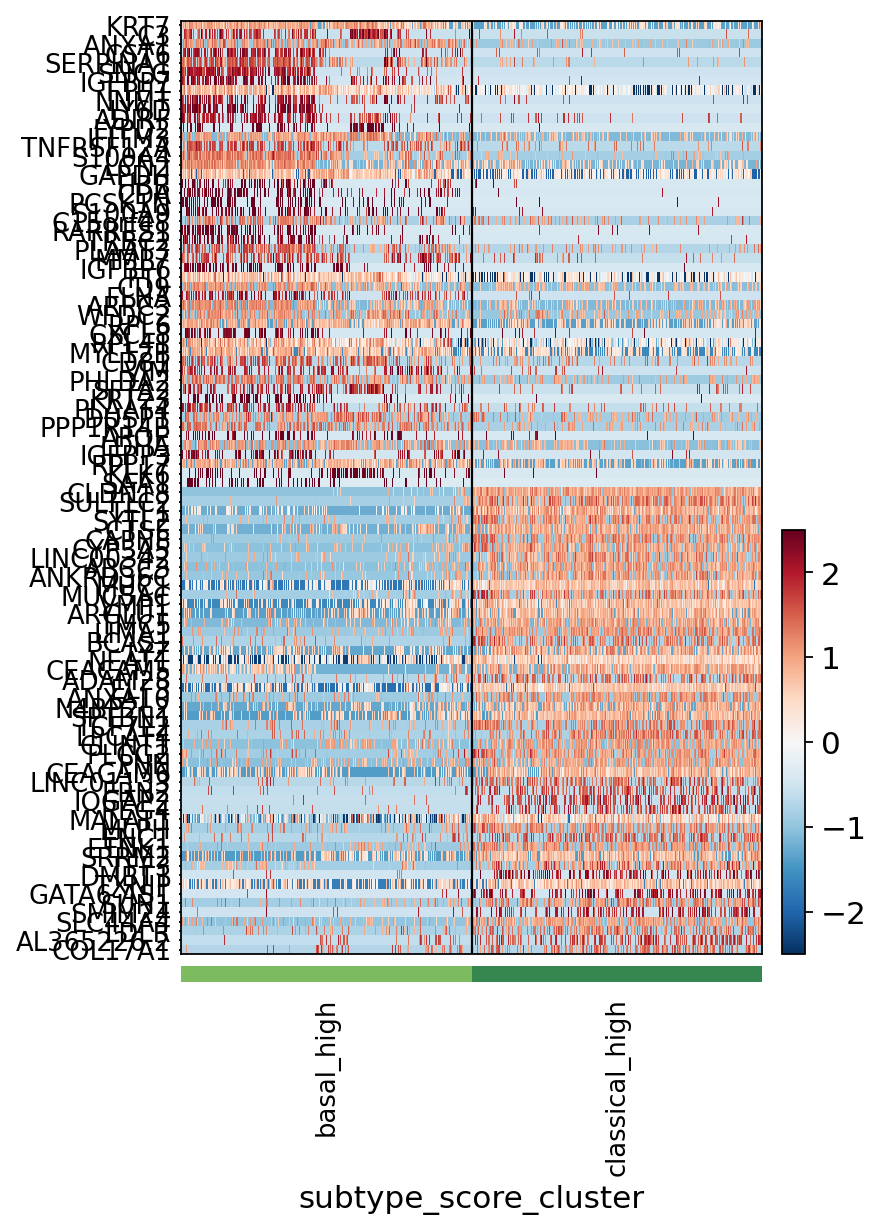

In [14]:
import scanpy as sc
import numpy as np


sc.pp.scale(adata_hi, zero_center=True, max_value=2.5, copy=False)
maxabs = np.max(np.abs(adata_hi.X))
sc.pl.heatmap(
    adata_hi,
    var_names=selected_genes,  
    groupby='subtype_score_cluster',  
    use_raw=False, 
    cmap='RdBu_r',  
    figsize=(5, 8),  
    show_gene_labels=True, 
    dendrogram=False,  
    standard_scale=None,  
    vmin=-maxabs, 
    vmax=maxabs,  
     swap_axes=True,
     save='X10.heatmap_KRT17_related-dc2_rdbu.pdf' 
)


In [15]:
gene_expression = adata_hi.to_df()
lypla1_expression = gene_expression['ZDHHC7'].values
correlations = np.zeros(gene_expression.shape[1])
for i in range(gene_expression.shape[1]):
    correlations[i] = pearsonr(lypla1_expression, gene_expression.iloc[:, i].values)[0]

lypla1_correlations = pd.Series(correlations, index=gene_expression.columns)
top_50_related = lypla1_correlations.sort_values(ascending=False).index[1:51]  
bottom_50_related = lypla1_correlations.sort_values().index[:50]
selected_genes = list(top_50_related) + list(bottom_50_related)
selected_gene_expression = adata_hi[:, selected_genes].to_df()

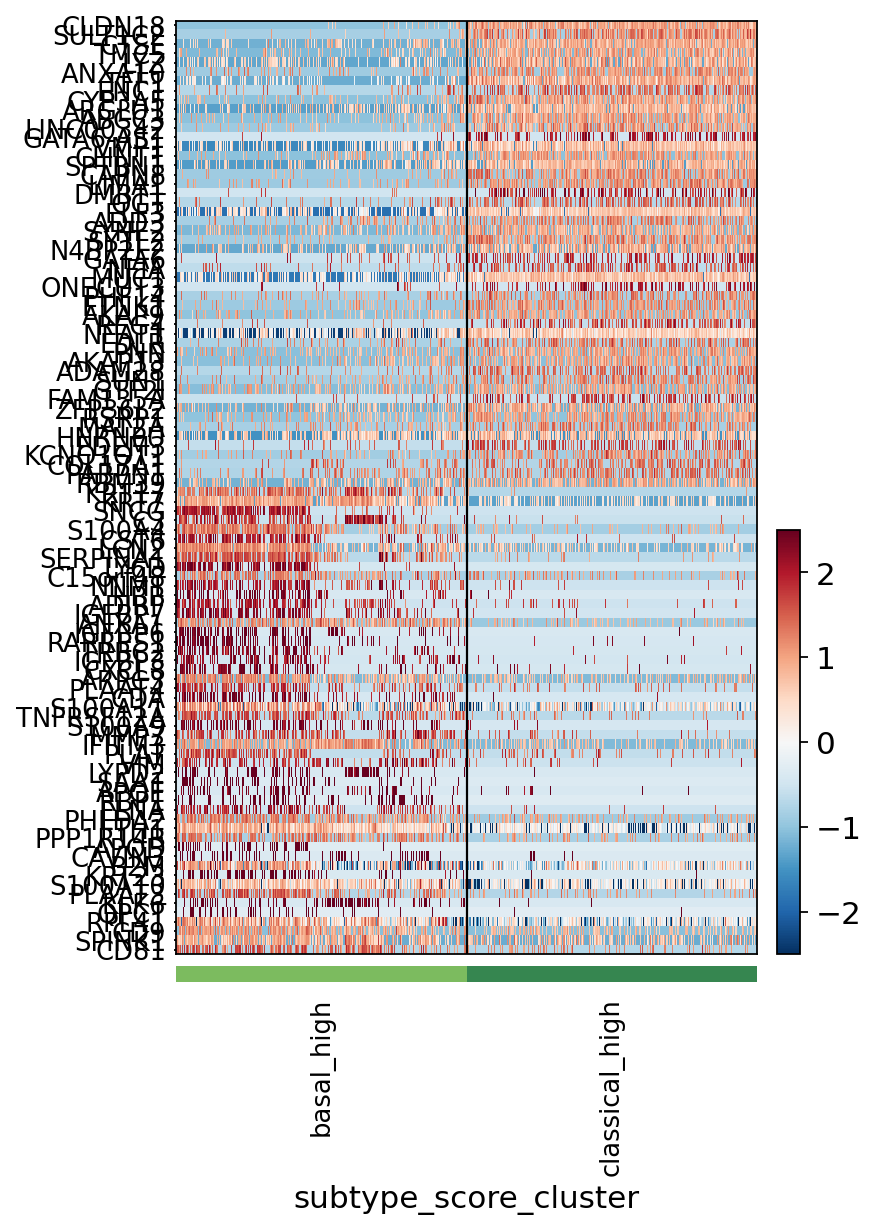

In [16]:
import scanpy as sc
import numpy as np

sc.pp.scale(adata_hi, zero_center=True, max_value=2.5, copy=False)
maxabs = np.max(np.abs(adata_hi.X))

sc.pl.heatmap(
    adata_hi,
    var_names=selected_genes,  
    groupby='subtype_score_cluster',  
    use_raw=False,  
    cmap='RdBu_r',  
    figsize=(5, 8),  
    show_gene_labels=True, 
    dendrogram=False, 
    standard_scale=None, 
    vmin=-maxabs,  
    vmax=maxabs,   
     swap_axes=True,
     save='X10.heatmap_ZDHHC7_related-dc2_rdbu.pdf' 
)


In [17]:
gene_expression = adata_hi.to_df()
lypla1_expression = gene_expression['PTPN11'].values
correlations = np.zeros(gene_expression.shape[1])
for i in range(gene_expression.shape[1]):
    correlations[i] = pearsonr(lypla1_expression, gene_expression.iloc[:, i].values)[0]

lypla1_correlations = pd.Series(correlations, index=gene_expression.columns)
top_50_related = lypla1_correlations.sort_values(ascending=False).index[1:51] 
bottom_50_related = lypla1_correlations.sort_values().index[:50]

selected_genes = list(top_50_related) + list(bottom_50_related)
selected_gene_expression = adata_hi[:, selected_genes].to_df()

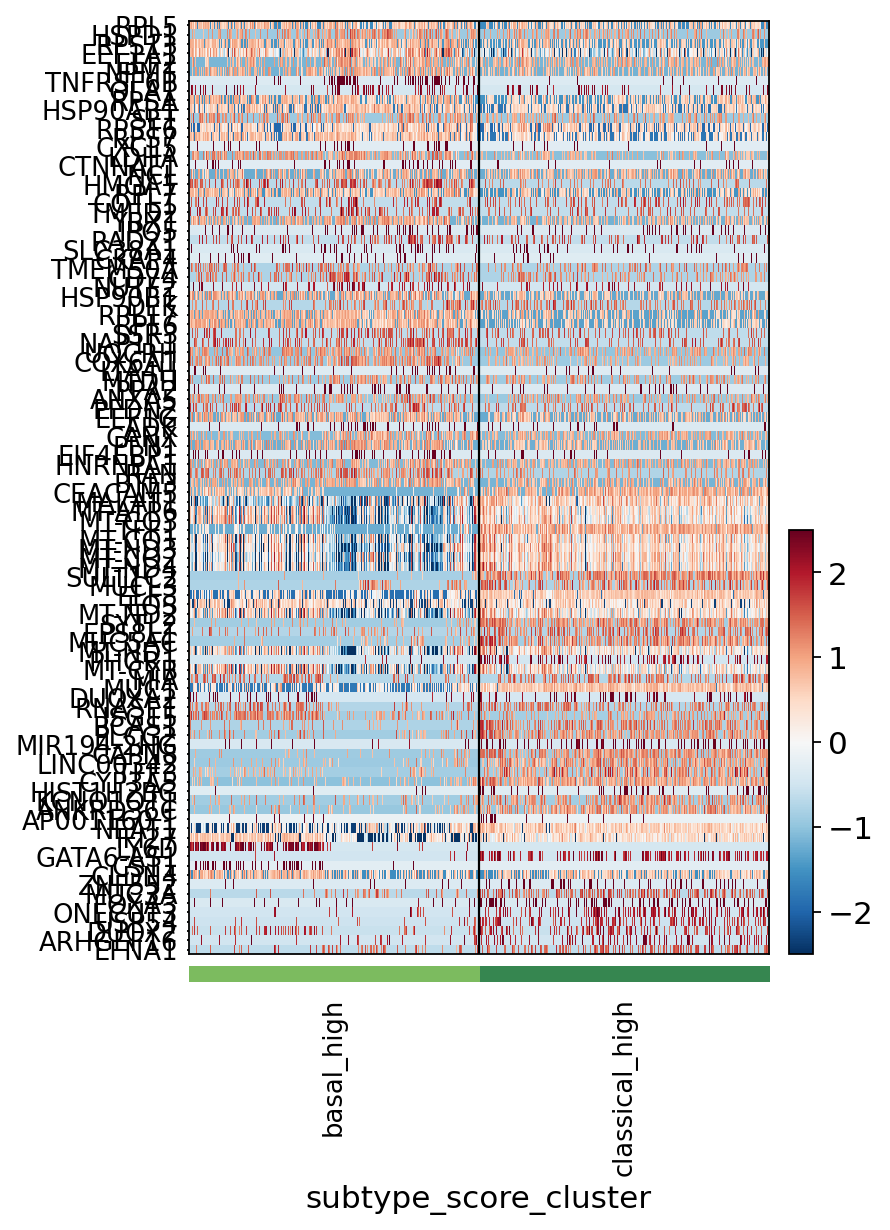

In [18]:
import scanpy as sc
import numpy as np


sc.pp.scale(adata_hi, zero_center=True, max_value=2.5, copy=False)
maxabs = np.max(np.abs(adata_hi.X))
sc.pl.heatmap(
    adata_hi,
    var_names=selected_genes,  
    groupby='subtype_score_cluster', 
    use_raw=False,  
    cmap='RdBu_r',  
    figsize=(5, 8), 
    show_gene_labels=True,  
    dendrogram=False, 
    standard_scale=None,  
    vmin=-maxabs, 
    vmax=maxabs,  
     swap_axes=True,
     save='X10.heatmap_PTPN11_related-dc2_rdbu.pdf' 
)
